# Reflection FWI · where the velocity gradient comes from

For reflection waveform inversion (RWI) the velocity gradient splits into four terms
(Wu & Alkhalifah, 2015, eq. 15–17):

$$\frac{\partial J}{\partial v} = \underbrace{\mathrm{I}}_{\text{transmission}}
  + \underbrace{\mathrm{II}+\mathrm{III}+\mathrm{IV}}_{\text{reflection}},\qquad
  \frac{\partial J}{\partial w} = \mathrm{I}.$$

In sweep those two halves come from **two different equations**, and this notebook plots them
side by side:

| solver | receiver field | gradient it produces | sensitivity |
|---|---|---|---|
| `Acoustic` | `h1` (background $p$) | **I** $=\langle\lambda, B'(v)p\rangle$ | direct / diving waves |
| `AcousticLSRTM` | `sh1` (scattered $q$) | **II+III+IV** | reflection wavepath + image point |

`AcousticLSRTM` is a two-field Born engine: a background field `h1` plus a scattered field
`sh1` driven by the reflectivity coupling $w\,v^2\nabla^2 h1$. Because $v$ enters that step in
**three** places (background propagation → IV, scattered propagation → II, scattered source →
III) its gradient carries three terms, while `Acoustic` — where $v$ enters once — carries one.

The two halves are complementary, but only when they share **one residual**: we therefore run
both solvers in a single objective and give each its own autograd leaf for $v$, so one
`backward()` separates I from II+III+IV without any hand-written adjoint.

Sections 1–4 work in 2-D on the paper's own geometry; section 5 repeats the experiment with
the 3-D twins `Acoustic3D` / `AcousticLSRTM3D`, where the reflection wavepath and the image
point take on their true volumetric shapes.

## 1. Setup — the paper's two-layer experiment

In [1]:
import os, sys, pathlib

_repo = pathlib.Path().resolve().parents[1]     # docs/notebooks/ -> repo root
if str(_repo / "src") not in sys.path:
    sys.path.insert(0, str(_repo / "src"))

import numpy as np
import torch
import matplotlib.pyplot as plt

from sweep.equations import Acoustic, Acoustic3D, AcousticLSRTM, AcousticLSRTM3D
from sweep.propagator import BoundarySaving, PropTorch, SPLIT_III_ENV, last_grad_split_iii

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [2]:
# Wu & Alkhalifah (2015) Figure 1 geometry: 2000 m/s over 3000 m/s, flat reflector at 5 km,
# one source at 2.5 km and one receiver at 12.5 km on the surface.
dh, (nz, nx) = 40.0, (175, 375)                   # 7 km deep x 15 km wide
iface = int(5000 / dh)
src_x, rec_x = int(2500 / dh), int(12500 / dh)

vp = np.full((nz, nx), 2000.0, np.float32); vp[iface:] = 3000.0
w  = np.zeros((nz, nx), np.float32);         w[iface]  = 0.05     # reflectivity on the interface

order, abcn = 8, 30      # 8th order in space: see the dispersion note below
dt, nt, fm, delay = 0.004, 2000, 6.0, 0.20        # 8 s record, 6 Hz Ricker

def ricker(nt, dt, fm, delay):
    t = np.arange(nt) * dt - delay
    a = (np.pi * fm * t) ** 2
    return ((1 - 2 * a) * np.exp(-a)).astype(np.float32)

wave = torch.tensor(ricker(nt, dt, fm, delay), device=device)
src  = np.array([[src_x, 1]], np.int32)
rec  = np.array([[[rec_x, 1]]], np.int32)
extent = [0, nx * dh / 1000, nz * dh / 1000, 0]

**A note on the grid.** A 6 Hz Ricker still carries useful energy out to roughly
$2.5 f_m \approx 15$ Hz, where the shortest wavelength is $2000/15 \approx 133$ m — only
$133/40 \approx 3.3$ points per wavelength on this 40 m grid. That is below the ~5 ppw a
4th-order stencil wants, and a 4th-order run shows it: fine ripples trail the outer arcs of the
gradient. Going to **8th order** costs almost nothing here and brings the result much closer to a
twice-refined reference (interior $\cos$ 0.95 → 0.99), which is why `order = 8` above. Refining
`dh` instead would work too, at ~8x the cost (4x the cells and half the time step).

## 2. One objective, two solvers

`Acoustic` records the background field, `AcousticLSRTM` the scattered field, and the modelled
data is their sum $\mathcal C(p+q)$. Both run on the compiled `c` backend in **full (store-all)**
mode, which is the mode that computes the LSRTM tomographic `vp` gradient on this branch.

Giving the two solvers **separate `vp` leaves** with the *same* loss is what isolates the terms:
one `backward()` writes I into `vp_ac.grad` and II+III+IV into `vp_ls.grad`, both driven by the
identical residual. (Running the solvers in separate losses would differentiate two *different*
objectives and the halves would no longer add up.)

In [3]:
def build(equation_cls, receiver):
    eq = equation_cls(spatial_order=order, device=device, backend="torch")
    return PropTorch(eq, shape=(nz, nx), dev=device, dh=dh, dt=dt, nt=nt, B=1,
                     source_type=["h1"], receiver_type=[receiver], abcn=abcn,
                     free_surface=False, pml_type="cpmlr", backend="torch",
                     impl="c", memory=BoundarySaving())   # low-memory production path

def split_gradients():
    """One loss, two vp leaves -> (term I, terms II+III+IV) under the SAME residual."""
    vp_ac = torch.tensor(vp, device=device, requires_grad=True)   # sees Acoustic only
    vp_ls = torch.tensor(vp, device=device, requires_grad=True)   # sees LSRTM only
    ref   = torch.tensor(w,  device=device, requires_grad=True)
    Cp = build(Acoustic,      "h1")(wave, src, rec, models=[vp_ac])
    Cq = build(AcousticLSRTM, "sh1")(wave, src, rec, models=[vp_ls, ref])
    loss = 0.5 * ((Cp + Cq) ** 2).sum()        # obs = 0 -> residual = the modelled data
    loss.backward()
    return vp_ac.grad.cpu().numpy(), vp_ls.grad.cpu().numpy(), ref.grad.cpu().numpy()

g_I, g_refl, g_m = split_gradients()            # I  |  II+III+IV  |  dJ/dm
g_total = g_I + g_refl
print(f"dJ/dvp  Acoustic       |I|         = {np.linalg.norm(g_I):.3e}")
print(f"dJ/dvp  AcousticLSRTM  |II+III+IV| = {np.linalg.norm(g_refl):.3e}"
      f"   ({100*np.linalg.norm(g_refl)/np.linalg.norm(g_I):.1f}% of |I|)")
print(f"dJ/dm   AcousticLSRTM  |dJ/dm|     = {np.linalg.norm(g_m):.3e}")

# Paper eq. 15 says dJ/dw = I.  sweep's `m` is a dimensionless reflectivity while the paper's `w`
# is a velocity perturbation, so the two differ by exactly 2/v -- check it.
cosang = lambda a, b: float(a.ravel() @ b.ravel() / (np.linalg.norm(a) * np.linalg.norm(b)))
print("")
print(f"check  dJ/dm * (2/v)  vs  I :  cos = {cosang(g_I, (2.0 / vp) * g_m):.6f}"
      f"   amplitude ratio = {np.linalg.norm(g_I) / np.linalg.norm((2.0 / vp) * g_m):.4f}")

# Both halves must be non-zero: a mode that silently returns a zero vp gradient would make
# every comparison below pass trivially (0 == 0).
assert np.linalg.norm(g_I) > 1e-20, "term I is zero"
assert np.linalg.norm(g_refl) > 1e-20, "II+III+IV is zero -- this memory mode has no LSRTM vp gradient"

dJ/dvp  Acoustic       |I|         = 3.774e-03
dJ/dvp  AcousticLSRTM  |II+III+IV| = 7.599e-05   (2.0% of |I|)
dJ/dm   AcousticLSRTM  |dJ/dm|     = 3.776e+00

check  dJ/dm * (2/v)  vs  I :  cos = 1.000000   amplitude ratio = 1.0000


### The halves really do add up

With a **single shared** `vp` leaf the same objective gives the complete $\partial J/\partial v$
directly. It must equal the sum of the two halves above — that is the check that the split is a
decomposition and not two unrelated gradients.

In [4]:
def joint_gradient():
    """Both solvers on ONE vp leaf -> the complete dJ/dv = I+II+III+IV."""
    vp_j = torch.tensor(vp, device=device, requires_grad=True)
    ref  = torch.tensor(w,  device=device, requires_grad=True)
    Cp = build(Acoustic,      "h1")(wave, src, rec, models=[vp_j])
    Cq = build(AcousticLSRTM, "sh1")(wave, src, rec, models=[vp_j, ref])
    (0.5 * ((Cp + Cq) ** 2).sum()).backward()
    return vp_j.grad.cpu().numpy()

g_joint = joint_gradient()
rel = np.linalg.norm(g_joint - g_total) / np.linalg.norm(g_joint)
cos = float(g_joint.ravel() @ g_total.ravel() /
            (np.linalg.norm(g_joint) * np.linalg.norm(g_total)))
print(f"I + (II+III+IV)  vs  joint dJ/dv :  cos = {cos:.6f}   rel = {rel:.2e}")

I + (II+III+IV)  vs  joint dJ/dv :  cos = 1.000000   rel = 0.00e+00


## 3. The two sensitivities, side by side

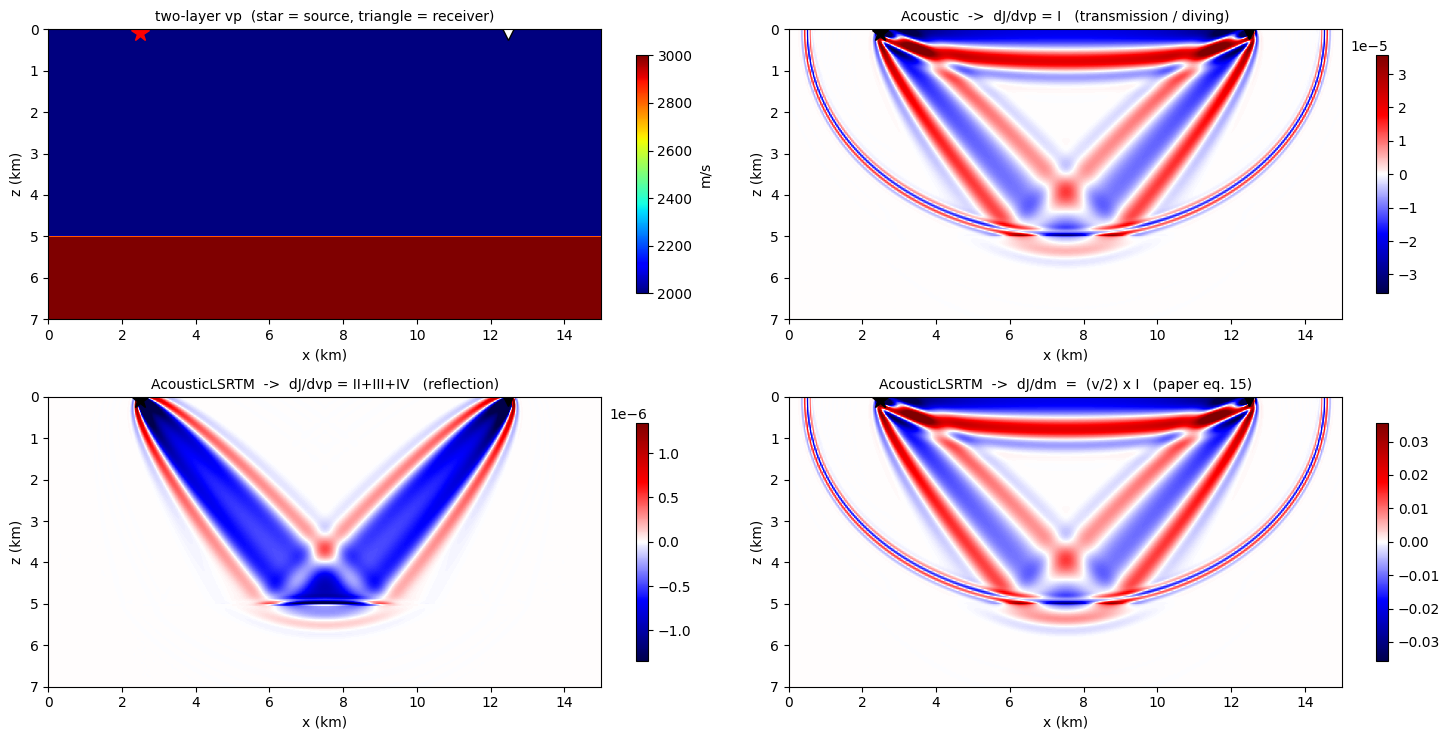

In [5]:
def panel(ax, field, title, ref=None, cmap="seismic"):
    clip = np.percentile(np.abs(field if ref is None else ref), 99.5)
    im = ax.imshow(field, extent=extent, aspect="auto", vmin=-clip, vmax=clip, cmap=cmap)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("x (km)"); ax.set_ylabel("z (km)")
    ax.plot(src_x * dh / 1000, 0.08, "k*", ms=12)
    ax.plot(rec_x * dh / 1000, 0.08, "kv", ms=9)
    return im

fig, ax = plt.subplots(2, 2, figsize=(15, 7.5))
im = ax[0, 0].imshow(vp, extent=extent, aspect="auto", cmap="jet")
ax[0, 0].set_title("two-layer vp  (star = source, triangle = receiver)", fontsize=10)
ax[0, 0].set_xlabel("x (km)"); ax[0, 0].set_ylabel("z (km)")
ax[0, 0].plot(src_x * dh / 1000, 0.08, "r*", ms=13)
ax[0, 0].plot(rec_x * dh / 1000, 0.08, "wv", ms=10, mec="k")
fig.colorbar(im, ax=ax[0, 0], shrink=0.82, label="m/s")

for a, (f, t, r) in zip(ax.ravel()[1:], [
        (g_I,     "Acoustic  ->  dJ/dvp = I   (transmission / diving)", None),
        (g_refl,  "AcousticLSRTM  ->  dJ/dvp = II+III+IV   (reflection)", None),
        (g_m,     "AcousticLSRTM  ->  dJ/dm  =  (v/2) x I   (paper eq. 15)",  None)]):
    fig.colorbar(panel(a, f, t, r), ax=a, shrink=0.82)
fig.tight_layout()

Reading the panels:

- **`Acoustic` → $\partial J/\partial v_p$ = I** is the standard-FWI kernel: broad transmission
  arcs sweeping from source to receiver. It *also* carries a reflection response at 5 km — the
  interface is a genuine velocity contrast inside `vp`, so the background field reflects off it too.
- **`AcousticLSRTM` → $\partial J/\partial v_p$ = II+III+IV** is the reflection sensitivity
  *generated by the reflectivity model* `m`: the two "rabbit ear" wavepaths running
  source → reflector → receiver, plus the localized image-point response at 5 km depth (term III,
  the singular part the paper weights with $\beta$). The direct/diving arcs are absent — this is
  the low-wavenumber update RWI adds where diving waves never reach, and it is exactly the anatomy
  of the paper's Figure 1, which is plotted from the scattered data alone.
- **`AcousticLSRTM` → $\partial J/\partial m$** looks like the first panel *because it is the same
  field*: the paper's eq. 15 states $\partial J/\partial w = \mathrm{I}$, and the check printed
  above confirms it here to $\cos = 1.000000$ once the parameterization factor is removed
  ($m$ is a dimensionless reflectivity, the paper's $w$ a velocity perturbation — exactly $2/v$
  apart, hence the ~1000x magnitude gap). Both are the correlation of the same adjoint with the
  same background field.

So this problem really carries **two** distinct sensitivities, not three: the transmission kernel
$\mathrm{I}$ (which doubles as the reflectivity update) and the reflection kernel
$\mathrm{II{+}III{+}IV}$.

**Why the total $\partial J/\partial v_p = \mathrm{I}+\mathrm{II}+\mathrm{III}+\mathrm{IV}$ is not
plotted:** with this geometry the reflection half is only ~2 % of term I (printed above), so the
sum is visually indistinguishable from the first gradient panel. The scattered field is linear in
`m`, and here `m = 0.05` on a single-cell reflector. That imbalance is precisely why the paper
plots II+III+IV alone in Figure 1, and why RWI carries the weights $\alpha$ (whole gradient) and
$\beta$ (term III) to rebalance the two contributions.

## 4. Weighting term III — the paper's $\beta$

Term III is the singular image-point response, concentrated right on the reflector; left as is,
it dominates the reflection update with high-wavenumber energy that belongs to the
reflectivity, not the background. Wu & Alkhalifah (2015, eq. 18–20) therefore weight it on its
own:

$$\nabla_v J = (\mathrm{II} + \mathrm{IV}) + \beta\,\mathrm{III}.$$

Set `SWEEP_LSRTM_SPLIT_III=1` and the compiled backward (full or boundary-saving mode) keeps
III apart: `vp.grad` then holds **II+IV** only, and `last_grad_split_iii()` returns **III** on the
same grid, so any $\beta$ is one line. Unset, nothing changes — `vp.grad` is the sum.

|III| / |II+IV| = 0.052   (III is a real share of the update, not a vanishing term)
(II+IV) + III  vs  unsplit vp.grad :  rel = 3.9e-08
III within +/-2 cells of the reflector : 100.0 %


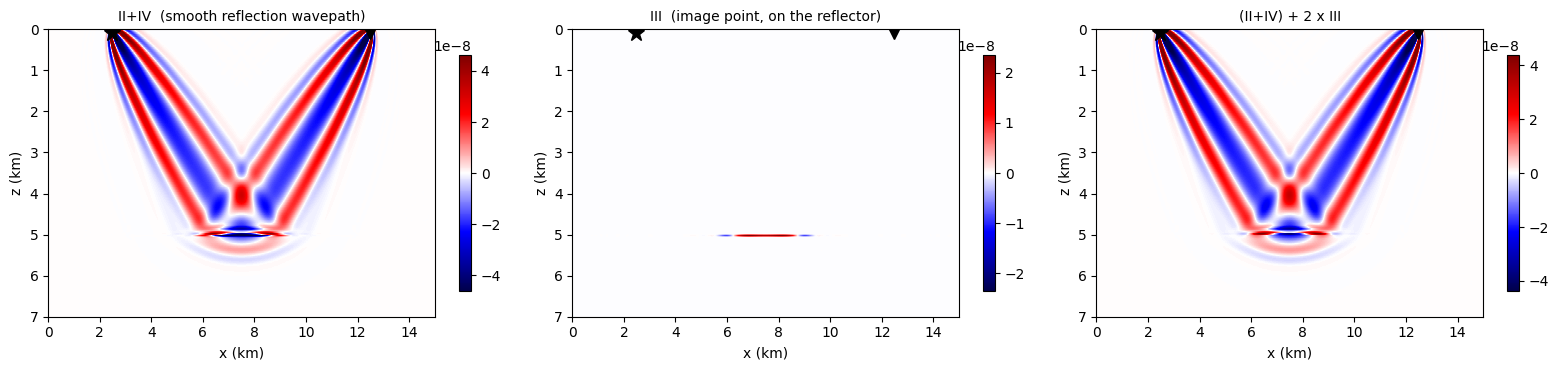

In [6]:
def lsrtm_split():
    """Scattered data alone, III split out: returns (II+IV, III)."""
    os.environ[SPLIT_III_ENV] = "1"
    try:
        vp_ls = torch.tensor(vp, device=device, requires_grad=True)
        ref   = torch.tensor(w,  device=device, requires_grad=True)
        Cq = build(AcousticLSRTM, "sh1")(wave, src, rec, models=[vp_ls, ref])
        (0.5 * (Cq ** 2).sum()).backward()
        return vp_ls.grad.cpu().numpy(), last_grad_split_iii().cpu().numpy()
    finally:
        os.environ.pop(SPLIT_III_ENV, None)

g_ii_iv, g_iii = lsrtm_split()
# The split is a decomposition of the same gradient, not a different one.
# (g_refl above is II+III+IV from the joint objective; this run sees the
# scattered data alone, so compare against an LSRTM-only unsplit run.)
vp_ref = torch.tensor(vp, device=device, requires_grad=True)
Cq = build(AcousticLSRTM, "sh1")(wave, src, rec, models=[vp_ref, torch.tensor(w, device=device)])
(0.5 * (Cq ** 2).sum()).backward()
g_unsplit = vp_ref.grad.cpu().numpy()
rel = np.linalg.norm(g_unsplit - (g_ii_iv + g_iii)) / np.linalg.norm(g_unsplit)
on_reflector = np.abs(g_iii[iface - 2:iface + 3]).sum() / np.abs(g_iii).sum()
print(f"|III| / |II+IV| = {np.linalg.norm(g_iii) / np.linalg.norm(g_ii_iv):.3f}"
      f"   (III is a real share of the update, not a vanishing term)")
print(f"(II+IV) + III  vs  unsplit vp.grad :  rel = {rel:.1e}")
print(f"III within +/-2 cells of the reflector : {100 * on_reflector:.1f} %")

beta = 2.0
fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
# III lives on one row of cells (0.6 % of the grid), so a percentile over the
# whole field lands in the tail of its tiny values and saturates the panel --
# clip it on its non-zero support instead.
for a, (f, t, r) in zip(ax, [(g_ii_iv, "II+IV  (smooth reflection wavepath)", None),
                             (g_iii, "III  (image point, on the reflector)", g_iii[g_iii != 0]),
                             (g_ii_iv + beta * g_iii, f"(II+IV) + {beta:g} x III", None)]):
    fig.colorbar(panel(a, f, t, r), ax=a, shrink=0.82)
fig.tight_layout()

## 5. The same anatomy in 3-D

`Acoustic3D` and `AcousticLSRTM3D` carry the same two halves, so the split is unchanged: one
objective, one `vp` leaf per solver, and `SPLIT_III_ENV` for term III. The geometry is the
paper's, scaled by one half (reflector at 2.5 km, source at 1.25 km, receiver at 6.25 km) with
the grid spacing, wavelet and stencil order of section 1 — so the dispersion note still holds —
and a 4 km crossline extent, wide enough that nothing below is cut off by the absorbing band.
Source and receiver sit on the centre line $y = 2$ km.

In [7]:
nz3, ny3, nx3 = 88, 100, 188                      # 3.5 km deep, 4 km crossline, 7.5 km inline
iface3 = int(2500 / dh)
vp3 = np.full((nz3, ny3, nx3), 2000.0, np.float32); vp3[iface3:] = 3000.0
w3 = np.zeros((nz3, ny3, nx3), np.float32);         w3[iface3] = 0.05
y0, sx3, rx3 = ny3 // 2, int(1250 / dh), int(6250 / dh)
nt3 = 1100                                          # 4.4 s: the reflection arrives by ~3.5 s
wave3 = torch.tensor(ricker(nt3, dt, fm, delay), device=device)
src3 = np.array([[[sx3, y0, 1]]], np.int64)        # (x, y, z)
rec3 = np.array([[[rx3, y0, 1]]], np.int64)

def build3(equation_cls, receiver):
    eq = equation_cls(spatial_order=order, device=device, backend="torch")
    return PropTorch(eq, shape=(nz3, ny3, nx3), dev=device, dh=dh, dt=dt, nt=nt3,
                     source_type=["h1"], receiver_type=[receiver], abcn=abcn,
                     free_surface=False, pml_type="cpmlr", backend="torch",
                     impl="c", memory=BoundarySaving())

# one objective, two vp leaves -> I | II+III+IV | dJ/dm, as in section 2
vp_ac = torch.tensor(vp3, device=device, requires_grad=True)
vp_ls = torch.tensor(vp3, device=device, requires_grad=True)
ref3  = torch.tensor(w3,  device=device, requires_grad=True)
Cp = build3(Acoustic3D,      "h1")(wave3, src3, rec3, models=[vp_ac])
Cq = build3(AcousticLSRTM3D, "sh1")(wave3, src3, rec3, models=[vp_ls, ref3])
(0.5 * ((Cp + Cq) ** 2).sum()).backward()
g3_I, g3_refl, g3_m = (x.grad.cpu().numpy() for x in (vp_ac, vp_ls, ref3))

# term III on its own, as in section 4 (scattered data alone)
os.environ[SPLIT_III_ENV] = "1"
try:
    v = torch.tensor(vp3, device=device, requires_grad=True)
    Cq = build3(AcousticLSRTM3D, "sh1")(wave3, src3, rec3, models=[v, torch.tensor(w3, device=device)])
    (0.5 * (Cq ** 2).sum()).backward()
    g3_ii_iv, g3_iii = v.grad.cpu().numpy(), last_grad_split_iii().cpu().numpy()
finally:
    os.environ.pop(SPLIT_III_ENV, None)

for name, g in (("I", g3_I), ("II+III+IV", g3_refl), ("III", g3_iii)):
    assert np.linalg.norm(g) > 0, f"3-D term {name} is zero"
cosang = lambda a, b: float(a.ravel() @ b.ravel() / (np.linalg.norm(a) * np.linalg.norm(b)))
print(f"|II+III+IV| / |I| = {np.linalg.norm(g3_refl) / np.linalg.norm(g3_I):.3f}"
      f"   (2-D above: {np.linalg.norm(g_refl) / np.linalg.norm(g_I):.3f})")
print(f"eq. 15 in 3-D:  cos(I, (2/v) dJ/dm) = {cosang(g3_I, (2.0 / vp3) * g3_m):.6f}")
print(f"|III| / |II+IV| = {np.linalg.norm(g3_iii) / np.linalg.norm(g3_ii_iv):.3f};  III on the reflector plane: "
      f"{100 * np.abs(g3_iii[iface3 - 2:iface3 + 3]).sum() / np.abs(g3_iii).sum():.1f} %")

|II+III+IV| / |I| = 0.007   (2-D above: 0.020)
eq. 15 in 3-D:  cos(I, (2/v) dJ/dm) = 1.000000
|III| / |II+IV| = 0.025;  III on the reflector plane: 100.0 %


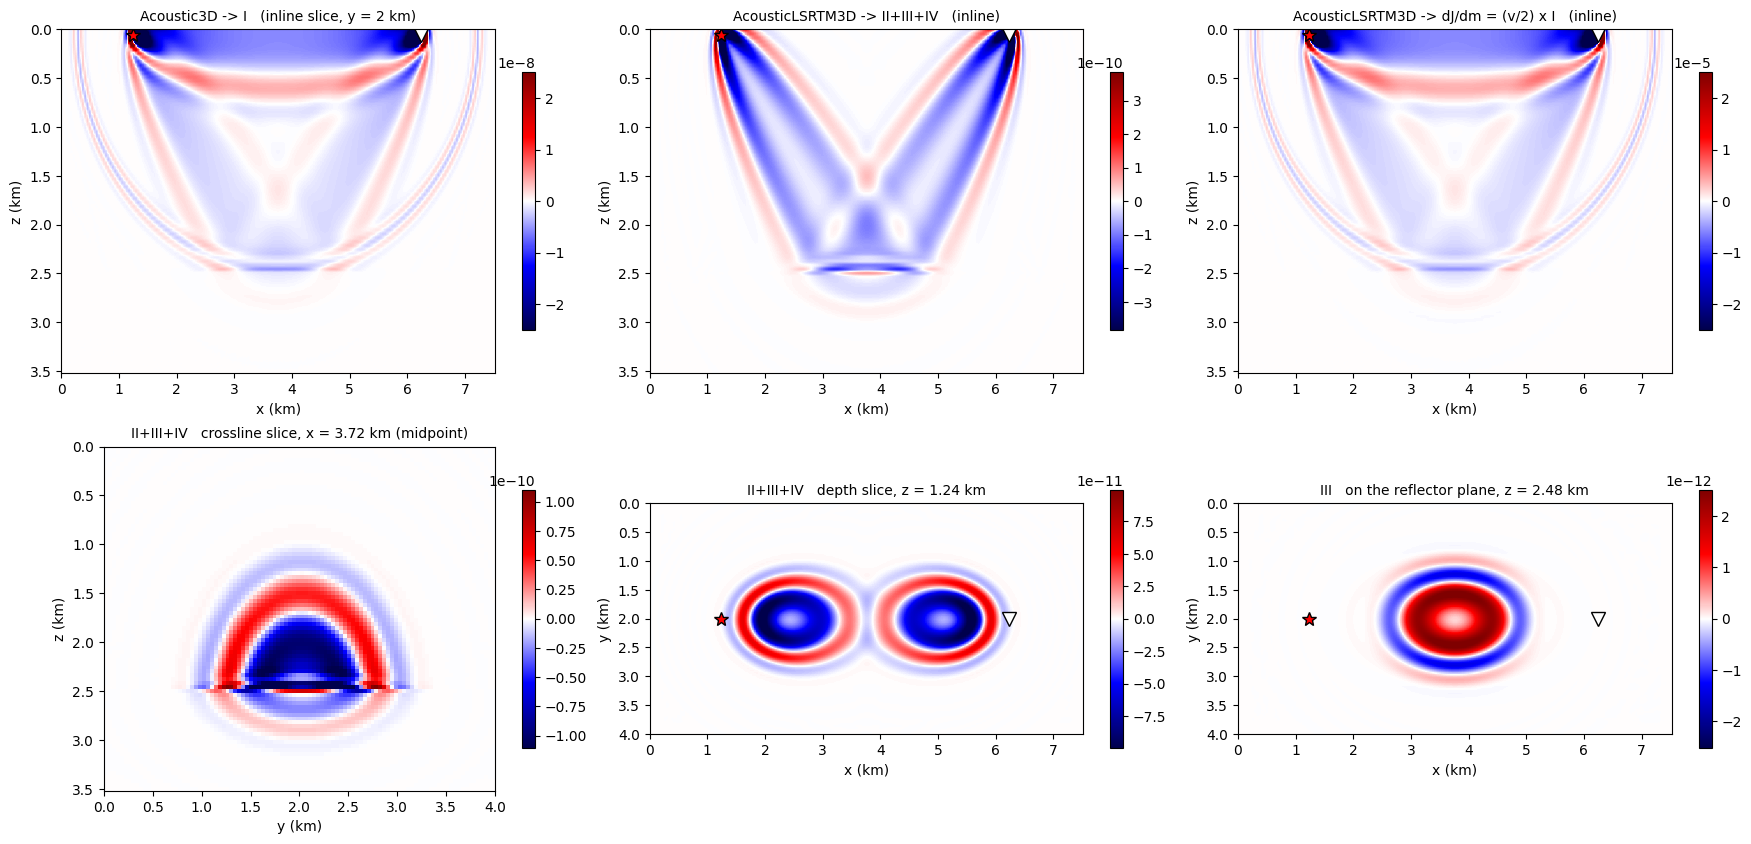

In [8]:
k = dh / 1000
def view(ax, f, title, ext, xl, yl, aspect="auto", marks=()):
    clip = np.percentile(np.abs(f), 99.5)
    im = ax.imshow(f, extent=ext, aspect=aspect, vmin=-clip, vmax=clip, cmap="seismic")
    ax.set_title(title, fontsize=10); ax.set_xlabel(xl); ax.set_ylabel(yl)
    for x, y, m in marks:
        ax.plot(x, y, m, ms=10, mec="k")
    fig.colorbar(im, ax=ax, shrink=0.75)

xz = [0, nx3 * k, nz3 * k, 0]; xy = [0, nx3 * k, ny3 * k, 0]; yz = [0, ny3 * k, nz3 * k, 0]
on_line = [(sx3 * k, 0.06, "r*"), (rx3 * k, 0.06, "wv")]
on_map  = [(sx3 * k, y0 * k, "r*"), (rx3 * k, y0 * k, "wv")]
xm, zh = (sx3 + rx3) // 2, iface3 // 2

fig, ax = plt.subplots(2, 3, figsize=(18, 8.5))
view(ax[0, 0], g3_I[:, y0, :],    "Acoustic3D -> I   (inline slice, y = 2 km)", xz, "x (km)", "z (km)", marks=on_line)
view(ax[0, 1], g3_refl[:, y0, :], "AcousticLSRTM3D -> II+III+IV   (inline)",   xz, "x (km)", "z (km)", marks=on_line)
view(ax[0, 2], g3_m[:, y0, :],    "AcousticLSRTM3D -> dJ/dm = (v/2) x I   (inline)", xz, "x (km)", "z (km)", marks=on_line)
view(ax[1, 0], g3_refl[:, :, xm], f"II+III+IV   crossline slice, x = {xm * k:.2f} km (midpoint)",
     yz, "y (km)", "z (km)", aspect="equal")
view(ax[1, 1], g3_refl[zh],       f"II+III+IV   depth slice, z = {zh * k:.2f} km",
     xy, "x (km)", "y (km)", aspect="equal", marks=on_map)
view(ax[1, 2], g3_iii[iface3],    f"III   on the reflector plane, z = {iface3 * k:.2f} km",
     xy, "x (km)", "y (km)", aspect="equal", marks=on_map)
fig.tight_layout()

Reading the 3-D panels:

- **Top row** is the 2-D anatomy again, now in the inline plane through source and receiver:
  transmission arcs in I, the clean source → reflector → receiver wavepath in II+III+IV, and
  $\partial J/\partial m$ repeating I (eq. 15 holds in 3-D just as in 2-D).
- **Crossline slice at the midpoint** — the reflection wavepath seen end-on: a dome resting on the
  reflector. It has a finite width across the line, the first Fresnel volume, which 2-D cannot
  represent at all.
- **Depth slice at half the reflector depth** — two rings, the cross-sections of the two legs
  (downgoing from the source, upgoing to the receiver). In 3-D each leg is a tube around its
  ray, hollow on axis: the banana-doughnut shape of finite-frequency sensitivity.
- **Term III on the reflector plane** — the image point becomes a patch: the Fresnel zone of the
  specular reflection, centred on the midpoint and slightly longer inline than crossline. In 2-D
  the same term is only a line segment.

Note the imbalance printed above: the reflection half is a smaller share of the total in 3-D
than in 2-D, because the doubly-spread reflected arrival decays faster than the direct and
diving waves. The paper's $\alpha$ / $\beta$ rebalancing matters at least as much in 3-D.

## 6. Which memory modes give the LSRTM `vp` gradient?

The tomographic `vp` gradient of `AcousticLSRTM` is available in:

| mode | how | `vp` gradient |
|---|---|---|
| **bs** (`memory=BoundarySaving()`, used here) | boundary-saves **both** fields and reconstructs them | yes (low memory) |
| **full** (`memory=Full()`) | store every wavefield | yes |
| ckpt / recursive (`memory=Ckpt(...)`) | background-only replay | no — `vp.grad` is 0 |

Prefer **bs**: it matches full to float32 roundoff (`cos = 1.000000`) at a fraction of the memory,
which is what makes an RWI loop practical. The tomographic term is computed only when `vp`
requires grad: it costs a second adjoint plus the scattered reconstruction (about twice the
backward, up to twice the memory), so a classic LSRTM with `vp` fixed runs the
reflectivity-only path at the old cost. The checkpointing modes replay the background field
only, so terms II/III/IV have nothing to correlate against and `vp.grad` comes back zero — the
`assert` in section 2 is there to catch exactly that. The `ref` (reflectivity) gradient is correct
in every mode. For a full RWI loop, alternate updates of the background
`v` (from the terms above) and the perturbation `w` (from `ref.grad`); a step that only
updates `w` can leave `vp` without `requires_grad` and skip the tomographic cost.

## Reference

Wu, Z., & Alkhalifah, T. (2015). Simultaneous inversion of the background velocity and the perturbation in full-waveform inversion. *Geophysics, 80*(6), R317–R329. [doi:10.1190/geo2014-0365.1](https://doi.org/10.1190/geo2014-0365.1) — the RWI gradient decomposition (eq. 15–20) this notebook reproduces.